In [1]:
!pip install pennylane --upgrade
!pip install qutip.qip
!pip install qutip
!pip install -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.0/130.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 47.8 MB/s eta 0:00:00
ERROR: You must give at least one requirement to install (see "pip help install")


In [2]:
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
import qutip as qt
from scipy.linalg import expm, sinm, cosm
from qutip_qip.operations import *
from qutip import Qobj, sigmax, sigmay, sigmaz , tensor, qeye,ptrace
import matplotlib.pyplot as plt

In [3]:
class QuantumCircuit:
    def __init__(self, num_qubits=2,eb=0.5,shot=1000):
        #entrada de dados
        self.num_qubits = num_qubits
        self.dev = qml.device("default.mixed", wires=self.num_qubits,shots=shot)
        self._phi_inicial =qml.QNode(self.__phi_inicial,self.dev)
        self._phi_final =qml.QNode(self.__phi_final,self.dev)
        self._caixa_SWAP =qml.QNode(self.__caixa_SWAP,self.dev)
        self._phi_entagled =qml.QNode(self.__phi_entagled,self.dev)
        self.eb=eb

    def thetas_c(self,bb=2,ea=1,ba=1):
    #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(-ba*ea/2)/Za
      p_b=np.exp(-bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)**1.5

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x
    def u_minus1(self,x):
        # Calculate the components
        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 - term2
        return np.array((u_minus).full())

    def u_plus1(self,x):
        # Calculate the components
        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 + term2
        return np.array((u_minus).full())

    def __phi_entagled(self,theta_A,theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])
        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(i+1)], wires=[i])
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])
        #conectar estados termalizados
        for i in range(1,int(self.num_qubits)-1):
          qml.CNOT(wires=[i,(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[(i+1)], wires=[i])
          qml.CNOT(wires=[i,(i+1)])
        return qml.state()

    def __phi_inicial(self,theta_A, theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])
        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
          for j in range(1,int(self.num_qubits/2)):
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))

    def __phi_final(self,theta_A,theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])
        #caixa de correlação
        for i in range(1,int(self.num_qubits/2)):
          for j in range(1,int(self.num_qubits/2)):
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        #caixa SWAP
        for i in range(1,int(self.num_qubits/2)):
          for j in range(1,int(self.num_qubits/2)):
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_plus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        #gerando uma lista com os fios
        wires_list1=[]
        wires_list2=[]
        for i in range(int(self.num_qubits/2)):
          wires_list1.append(i)
        for i in range(int(self.num_qubits/2)):
          wires_list2.append(i)
        return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))

    def __caixa_SWAP(self,x,rho):
      #gerando uma lista com os fios
      wires_list=[]
      for i in range(self.num_qubits):
        wires_list.append(i)
      qml.QubitDensityMatrix(rho, wires=wires_list)
      #caixa swap
      for i in range(self.num_qubits):
        qml.U3(x[i+0],x[i+1],x[i+2], wires=i)
      return qml.state()

    def hamiltoniana(self,eb,ea=1):
      #gerando a matriz identidade para gerar os circuitos
      resultfi=Qobj(qeye(2**(self.num_qubits-2)),dims=(cnot(self.num_qubits-2,0,1).dims))
      inteiro=int((self.num_qubits)/2)
      #gerando o hamiltoniano para Num Qubits
      for i in range(1,self.num_qubits-1):
        result1=Qobj(1)
        result2=Qobj(1)
        for j in range(1,self.num_qubits-1):
          if i==j and i<inteiro:
            result1=tensor(result1,-ea*qt.sigmaz()/2)
            result2=tensor(result2,qeye(2))
          elif i==j and i>=inteiro:
            result2=tensor(result2,-eb*qt.sigmaz()/2)
            result1=tensor(result1,qeye(2))
          else:
            result1=tensor(result1,qeye(2))
            result2=tensor(result2,qeye(2))
        resultfi=resultfi+Qobj(result1+result2,dims=cnot(self.num_qubits-2,0,1).dims)
      return resultfi
    #truque para gerar a biblioteca do penny lane com POO
    def phi_inicial(self,theta_A, theta_B,x=0.5):
      return self._phi_inicial(theta_A, theta_B,x)

    def phi_entagled(self,theta_A, theta_B,x=0.5):
      return self._phi_entagled(theta_A, theta_B,x)

    def draw(self):#resposta temporaria
      qml.draw_mpl(self.__phi_inicial)(1,1,0.5)
      return

    def caixa_SWAP(self,x,rho):
      return self._caixa_SWAP(x,rho)

    def phi_final(self,theta_A,theta_B,x=0.5):
      return self._phi_final(theta_A,theta_B,x)

class QuantumOptimization:
    dev=None
    def __init__(self,num_qubits=2,epsilon=0.05,eb=0.5):
        self.num_qubits = num_qubits
        self.epsilon=epsilon
        self.eb=eb
        self.trace=np.linspace(1,num_qubits-2,num_qubits-2,dtype=int)
        self.quantum_circuit = QuantumCircuit(self.num_qubits)
        #self.dev = qml.device("default.mixed", wires=self.num_qubits)
        #self.circuit = qml.QNode(self.__circuit, self.dev)

    def loss1(self, rho0, rhof, H):#loss baseado no trabalho
        return np.real(((qt.ptrace(rhof,self.trace) - qt.ptrace(rho0,self.trace)) * H).tr())

    def thetas_c(self,bb=2,ea=1,ba=1):
    #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(-ba*ea/2)/Za
      p_b=np.exp(-bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)**1.5

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x

    def loss_function(self, params):
        eb = self.eb
        A,B,x=self.thetas_c()
        rho = self.quantum_circuit.phi_entagled(A,B,x)
        rho=rho@np.conjugate(rho).T
        #print(rho)
        #print(self.circuit(params, rho))
        state = qt.Qobj(self.quantum_circuit.caixa_SWAP(params, rho), dims=cnot(self.num_qubits, 0, 1).dims)
        rho0 =  qt.Qobj(rho, dims=cnot(self.num_qubits, 0, 1).dims)
        rhof = state * state.dag()
        H = self.quantum_circuit.hamiltoniana(eb)

        return self.loss1(rho0, rhof, H)

    def parameter_shift_gradient(self, params, j):
        # metod do gradiente
        epsilon = self.epsilon
        shifted_params_plus = params.copy()
        shifted_params_plus[j] += epsilon

        shifted_params_minus = params.copy()
        shifted_params_minus[j] -= epsilon

        gradient = (
            self.loss_function(shifted_params_plus)
            - self.loss_function(shifted_params_minus)
        ) / (2 * epsilon)
        return gradient


    def stochastic_gradient_descent(self, params, learning_rate, num_epochs):
        epoch = 0
        loss = 0
        loss_vec = []
        epochs_vec = []
        #otimizando parametros
        while epoch < num_epochs:

            for j in range(len(params)):
                gradient = self.parameter_shift_gradient(params, j)
                params[j] -= learning_rate * np.real(gradient)

            loss = self.loss_function(params)
            loss_vec.append(loss)
            epochs_vec.append(epoch)
            print(f"Epoch {epoch+1}, Loss: {np.real(loss)}")
            epoch += 1
        return params, loss_vec, epochs_vec

class Plots:
  def __init__(self):
    pass
  def plotar(self,x,y,labelx=None,labely=None):
    plt.plot(x,y,'.')
    plt.ylabel(labely)
    plt.xlabel(labelx)
    plt.grid(True)
    plt.show()

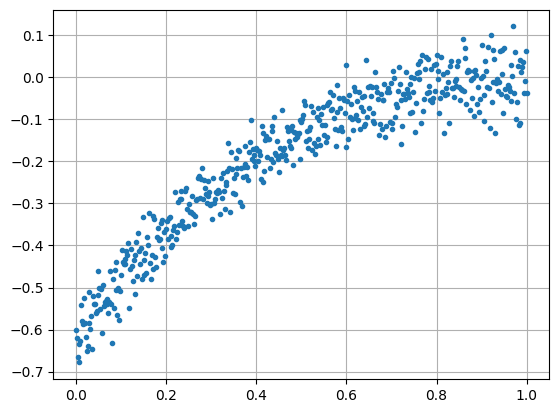

In [4]:
num_qubits=6
n=501
ebs=np.linspace(0,1,n)
expval=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
plot=Plots()
for i,eb in enumerate(ebs):
  Quan6=QuantumCircuit(num_qubits,eb)
  theta_a,theta_b,x=Quan6.thetas_c()
  expval1[i]=Quan6.phi_inicial(theta_a,theta_b,x)
  expval2[i]=Quan6.phi_final(theta_a,theta_b,x)
  expval[i]=-expval2[i]+expval1[i]

plot.plotar(ebs,expval)

In [5]:
class QuantumCircuit:
    def __init__(self, num_qubits=2,eb=0.5,shot=1000):
        #entrada de dados
        self.num_qubits = num_qubits
        self.dev = qml.device("default.mixed", wires=self.num_qubits,shots=shot)
        self._phi_inicial =qml.QNode(self.__phi_inicial,self.dev)
        self._phi_final =qml.QNode(self.__phi_final,self.dev)
        self._caixa_SWAP =qml.QNode(self.__caixa_SWAP,self.dev)
        self._phi_entagled =qml.QNode(self.__phi_entagled,self.dev)
        self.eb=eb

    def thetas_c(self,bb=2,ea=1,ba=1):
    #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(-ba*ea/2)/Za
      p_b=np.exp(-bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)**1.5

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x
    def u_minus1(self,x):
        # Calculate the components
        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 - term2
        return np.array((u_minus).full())

    def u_plus1(self,x):
        # Calculate the components
        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 + term2
        return np.array((u_minus).full())

    def __phi_entagled(self,theta_A,theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])
        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(i+1)], wires=[i])
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])
        #conectar estados termalizados
        for i in range(1,int(self.num_qubits)-1):
          qml.CNOT(wires=[i,(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[(i+1)], wires=[i])
          qml.CNOT(wires=[i,(i+1)])
        return qml.state()

    def __phi_inicial(self,theta_A, theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])
        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3))*0.5-0.5*((qml.PauliZ(4)+qml.PauliZ(5)+qml.PauliZ(6))))

    def __phi_final(self,theta_A,theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])
        #caixa de correlação
        for i in range(1,int(self.num_qubits/2)):
          for j in range(1,int(self.num_qubits/2)):
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        #caixa SWAP
        for i in range(1,int(self.num_qubits/2)):
          for j in range(1,int(self.num_qubits/2)):
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_plus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        if self.num_qubits==8:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3))*0.5-0.5*((qml.PauliZ(4)+qml.PauliZ(5)+qml.PauliZ(6))))
        elif self.num_qubits==6:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))

    def __caixa_SWAP(self,x,rho):
      #gerando uma lista com os fios
      wires_list=[]
      for i in range(self.num_qubits):
        wires_list.append(i)
      qml.QubitDensityMatrix(rho, wires=wires_list)
      #caixa swap
      for i in range(self.num_qubits):
        qml.U3(x[i+0],x[i+1],x[i+2], wires=i)
      return qml.state()

    def hamiltoniana(self,eb,ea=1):
      #gerando a matriz identidade para gerar os circuitos
      resultfi=Qobj(qeye(2**(self.num_qubits-2)),dims=(cnot(self.num_qubits-2,0,1).dims))
      inteiro=int((self.num_qubits)/2)
      #gerando o hamiltoniano para Num Qubits
      for i in range(1,self.num_qubits-1):
        result1=Qobj(1)
        result2=Qobj(1)
        for j in range(1,self.num_qubits-1):
          if i==j and i<inteiro:
            result1=tensor(result1,-ea*qt.sigmaz()/2)
            result2=tensor(result2,qeye(2))
          elif i==j and i>=inteiro:
            result2=tensor(result2,-eb*qt.sigmaz()/2)
            result1=tensor(result1,qeye(2))
          else:
            result1=tensor(result1,qeye(2))
            result2=tensor(result2,qeye(2))
        resultfi=resultfi+Qobj(result1+result2,dims=cnot(self.num_qubits-2,0,1).dims)
      return resultfi
    #truque para gerar a biblioteca do penny lane com POO
    def phi_inicial(self,theta_A, theta_B,x=0.5):
      return self._phi_inicial(theta_A, theta_B,x)

    def phi_entagled(self,theta_A, theta_B,x=0.5):
      return self._phi_entagled(theta_A, theta_B,x)

    def draw(self):#resposta temporaria
      qml.draw_mpl(self.__phi_inicial)(1,1,0.5)
      return

    def caixa_SWAP(self,x,rho):
      return self._caixa_SWAP(x,rho)

    def phi_final(self,theta_A,theta_B,x=0.5):
      return self._phi_final(theta_A,theta_B,x)

class QuantumOptimization:
    dev=None
    def __init__(self,num_qubits=2,epsilon=0.05,eb=0.5):
        self.num_qubits = num_qubits
        self.epsilon=epsilon
        self.eb=eb
        self.trace=np.linspace(1,num_qubits-2,num_qubits-2,dtype=int)
        self.quantum_circuit = QuantumCircuit(self.num_qubits)
        #self.dev = qml.device("default.mixed", wires=self.num_qubits)
        #self.circuit = qml.QNode(self.__circuit, self.dev)

    def loss1(self, rho0, rhof, H):#loss baseado no trabalho
        return np.real(((qt.ptrace(rhof,self.trace) - qt.ptrace(rho0,self.trace)) * H).tr())

    def thetas_c(self,bb=2,ea=1,ba=1):
    #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(-ba*ea/2)/Za
      p_b=np.exp(-bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)**1.5

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x

    def loss_function(self, params):
        eb = self.eb
        A,B,x=self.thetas_c()
        rho = self.quantum_circuit.phi_entagled(A,B,x)
        rho=rho@np.conjugate(rho).T
        #print(rho)
        #print(self.circuit(params, rho))
        state = qt.Qobj(self.quantum_circuit.caixa_SWAP(params, rho), dims=cnot(self.num_qubits, 0, 1).dims)
        rho0 =  qt.Qobj(rho, dims=cnot(self.num_qubits, 0, 1).dims)
        rhof = state * state.dag()
        H = self.quantum_circuit.hamiltoniana(eb)

        return self.loss1(rho0, rhof, H)

    def parameter_shift_gradient(self, params, j):
        # metod do gradiente
        epsilon = self.epsilon
        shifted_params_plus = params.copy()
        shifted_params_plus[j] += epsilon

        shifted_params_minus = params.copy()
        shifted_params_minus[j] -= epsilon

        gradient = (
            self.loss_function(shifted_params_plus)
            - self.loss_function(shifted_params_minus)
        ) / (2 * epsilon)
        return gradient


    def stochastic_gradient_descent(self, params, learning_rate, num_epochs):
        epoch = 0
        loss = 0
        loss_vec = []
        epochs_vec = []
        #otimizando parametros
        while epoch < num_epochs:

            for j in range(len(params)):
                gradient = self.parameter_shift_gradient(params, j)
                params[j] -= learning_rate * np.real(gradient)

            loss = self.loss_function(params)
            loss_vec.append(loss)
            epochs_vec.append(epoch)
            print(f"Epoch {epoch+1}, Loss: {np.real(loss)}")
            epoch += 1
        return params, loss_vec, epochs_vec

class Plots:
  def __init__(self):
    pass
  def plotar(self,x,y,labelx=None,labely=None):
    plt.plot(x,y,'.')
    plt.ylabel(labely)
    plt.xlabel(labelx)
    plt.grid(True)
    plt.show()

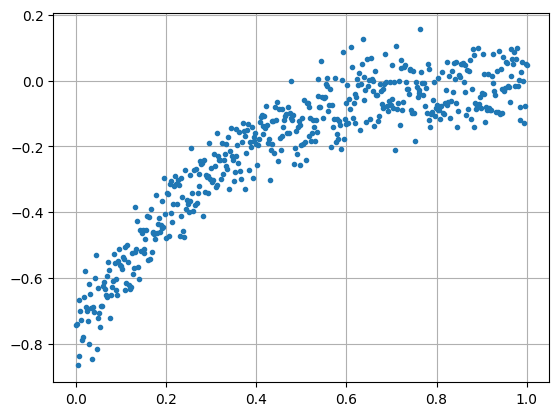

In [6]:
num_qubits=8
n=501
ebs=np.linspace(0,1,n)
expval=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
plot=Plots()
for i,eb in enumerate(ebs):
  Quan6=QuantumCircuit(num_qubits,eb)
  theta_a,theta_b,x=Quan6.thetas_c()
  expval1[i]=Quan6.phi_inicial(theta_a,theta_b,x)
  expval2[i]=Quan6.phi_final(theta_a,theta_b,x)
  expval[i]=-expval2[i]+expval1[i]

plot.plotar(ebs,expval)

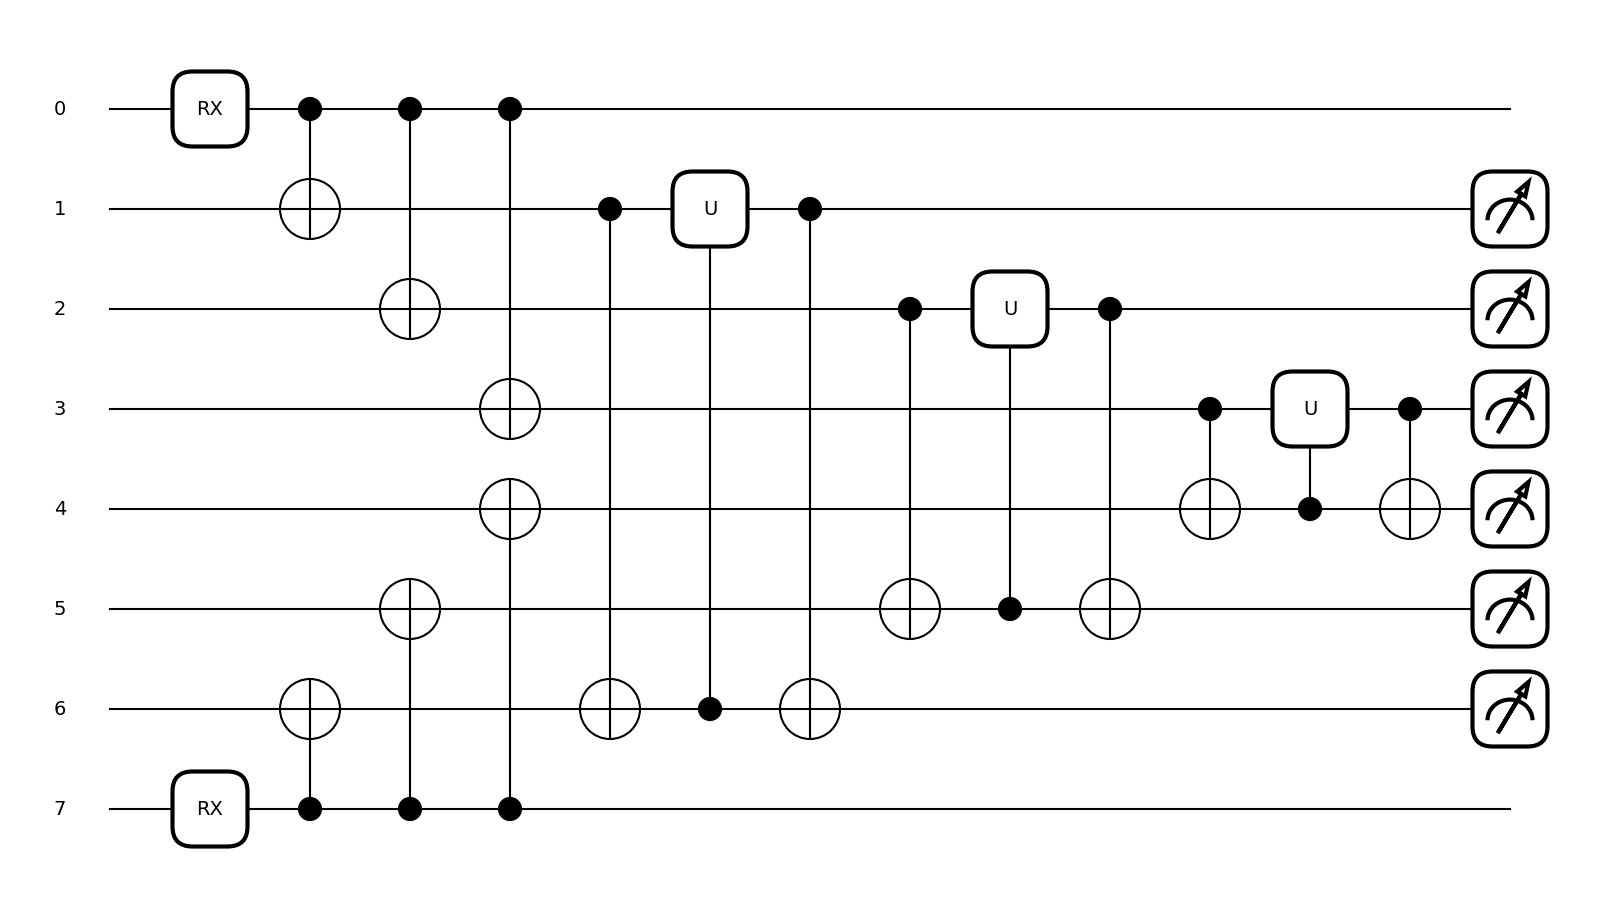

In [7]:
Quan6=QuantumCircuit(num_qubits,eb)
Quan6.draw()